# MAE 3127 - Fall 2025
# Laboratory: Venturi Tube Experiment
    
### Instructor and code author: Prof. Kartik Bulusu [MAE] 
    
#### Graduate Teaching Assistants: Bengisu Sisik [MAE], Swastika Bera [MAE]
#### Undergraduate Teaching Assistant: Salman Niazi [MAE]
#### Learning Assistant: Lucy Truemper [CEE]

Let's start by importing our favorite friends as always going forward in this class: **numpy**, **matplotlib**, and **pandas**

In [39]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

Before we get started with pandas, we are going to introduce a function called `help()` which will provide some information about functions we are working with!

In [40]:
#Here we ask python to tell us about the np.array function, but this works with everything!
help(np.array)

Help on built-in function array in module numpy:

array(...)
    array(object, dtype=None, *, copy=True, order='K', subok=False, ndmin=0,
          like=None)
    
    Create an array.
    
    Parameters
    ----------
    object : array_like
        An array, any object exposing the array interface, an object whose
        __array__ method returns an array, or any (nested) sequence.
    dtype : data-type, optional
        The desired data-type for the array.  If not given, then the type will
        be determined as the minimum type required to hold the objects in the
        sequence.
    copy : bool, optional
        If true (default), then the object is copied.  Otherwise, a copy will
        only be made if __array__ returns a copy, if obj is a nested sequence,
        or if a copy is needed to satisfy any of the other requirements
        (`dtype`, `order`, etc.).
    order : {'K', 'A', 'C', 'F'}, optional
        Specify the memory layout of the array. If object is not an array

Pandas is a library to work with dataframe objects. Dataframes are a way to represent data in rows and columns, much like a matrix!! 

A little vocab to get us started. I promise it won't be much. 
- The **columns** of a dataframe are called the **columns**
- The **rows** of the dataframe are called the **index** 

See that wasn't too bad :)

Last week we discussed importing data from a csv file into a pandas dataframe. We are going to bring that back and do a whole lot more with it this week! We have provided a `SampleData_VenturiTube.xlsx` file in this week's content for this demonstration! 



#### Here are the steps!
1. Locate place the file titled `SampleData_VenturiTube.xlsx` in the same folder as this jupyter notebook file

3. `Copy Path or Filenmake to Clipboard`; you may have to append `.xlsx` to the file name.

4. Establish a `filename` variable in a code cell that is an empty string using `filename = ''` as show in the cell below

5. Inside the quotes paste the path using `Ctrl+V` or `Cmd+V` on your keyboard

6. You should now have something like this: `filename = 'SampleData_VenturiTube.xlsx'`

7. Finally, use `data = pd.ExcelFile(filename)` to save your file into a pandas dataframe!


Today's `DemoCSV1.csv` originally comes from the module [vega_datasets](https://vega.github.io/vega-datasets/) if you are curious.

In [41]:
filename = 'SampleData_VenturiTube.xlsx'
data = pd.ExcelFile(filename)
df1 = pd.read_excel(data, 'Table1')
df2 = pd.read_excel(data, 'Table2')
df3 = pd.read_excel(data, 'Table3')

### Showing Dataframes
To show dataframes, we have a couple of options! First we can use what we did last week using the `display(df)` function which operates similarly to `print()`. We can also use `df.head()` and `df.tail()` which will just show parts of the frame. The `.head(n)` shows the first n lines of the frame, and the `.tail(m)` shows the last m lines of the frame

Let's try these out!

In [42]:
display(df1)

,(d_2/d_1),0.6153846154,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Tapping,l (mm),d (mm),A (mm^2),d_2/d_n,A_2/A_n,Ideal dim-less pressure
1,"A (upstream, h_1)",-54,26,530.929158,0.615385,0.378698,0
2,B,-34,23.2,422.732708,0.689655,0.475624,-0.082806
3,C,-22,18.4,265.904402,0.869565,0.756144,-0.428341
4,"D (throat, h_2)",-8,16,201.06193,1,1,-0.856588
5,E,7,16.79,221.406962,0.952948,0.90811,-0.681252
6,F,22,18.47,267.931436,0.86627,0.750423,-0.419722
7,G,37,20.16,319.20592,0.793651,0.629882,-0.253338
8,H,52,21.84,374.623614,0.732601,0.536704,-0.144639
9,J,67,23.53,434.844254,0.679983,0.462377,-0.07038


In [43]:
df1.head(4)

,(d_2/d_1),0.6153846154,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Tapping,l (mm),d (mm),A (mm^2),d_2/d_n,A_2/A_n,Ideal dim-less pressure
1,"A (upstream, h_1)",-54,26,530.929158,0.615385,0.378698,0
2,B,-34,23.2,422.732708,0.689655,0.475624,-0.082806
3,C,-22,18.4,265.904402,0.869565,0.756144,-0.428341


In [44]:
df1.tail(4)

,(d_2/d_1),0.6153846154,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
8,H,52,21.84,374.623614,0.732601,0.536704,-0.144639
9,J,67,23.53,434.844254,0.679983,0.462377,-0.07038
10,K,82,25.21,499.155169,0.634669,0.402804,-0.018839
11,L,102,26,530.929158,0.615385,0.378698,0


In [45]:
#Just to showcase it, let's use help(df.tail)
help(df1.tail)

Help on method tail in module pandas.core.generic:

tail(n: 'int' = 5) -> 'NDFrameT' method of pandas.core.frame.DataFrame instance
    Return the last `n` rows.
    
    This function returns last `n` rows from the object based on
    position. It is useful for quickly verifying data, for example,
    after sorting or appending rows.
    
    For negative values of `n`, this function returns all rows except
    the first `n` rows, equivalent to ``df[n:]``.
    
    Parameters
    ----------
    n : int, default 5
        Number of rows to select.
    
    Returns
    -------
    type of caller
        The last `n` rows of the caller object.
    
    See Also
    --------
    DataFrame.head : The first `n` rows of the caller object.
    
    Examples
    --------
    >>> df = pd.DataFrame({'animal': ['alligator', 'bee', 'falcon', 'lion',
    ...                    'monkey', 'parrot', 'shark', 'whale', 'zebra']})
    >>> df
          animal
    0  alligator
    1        bee
    2     fa

### Dataframe Shape

An **m** x **n** matrix has **m** rows and **n** columns. A dataframe also has rows and columns! Let's get the shape of the dataframe using `df1.shape`

`df1.shape` will return the `(number_of_rows, number_of_columns)`

In [46]:
df1.shape

(12, 7)

In [47]:
df2.shape

(15, 5)

In [48]:
df3.shape

(15, 5)

### Accessing Data within Frames

#### Let's start with the data frame `df1`.

Using the `df1.iloc['Row', 'Column']` function we can locate certain data. 

Last week we used this for plotting. We will get to that in a second. Let's pull out all the data starting with `row-index 1` and `column-index 1` in the dataframe `df1`.

In [49]:
x_values = df1.iloc[1:,1]

In [50]:
x_values

1     -54
2     -34
3     -22
4      -8
5       7
6      22
7      37
8      52
9      67
10     82
11    102
Name: 0.6153846154, dtype: object

In [51]:
ideal_dimLess_pressure = df1.iloc[1:,6]

In [52]:
ideal_dimLess_pressure 

1            0
2    -0.082806
3    -0.428341
4    -0.856588
5    -0.681252
6    -0.419722
7    -0.253338
8    -0.144639
9     -0.07038
10   -0.018839
11           0
Name: Unnamed: 6, dtype: object

#### Let's now work with the data frame `df2`.

Using the `df2.iloc['Row', 'Column']` function we can locate certain data. 

Last week we used this for plotting. We will get to that in a second. Let's pull out all the data starting with `row-index 4` and `column-index 4` in the dataframe `df2`.

In [53]:
actualQ1_dimLess_pressure = df2.iloc[4:,4]

In [54]:
actualQ1_dimLess_pressure

4            0
5    -0.070246
6    -0.477676
7    -1.137993
8    -0.983451
9    -0.660317
10   -0.491725
11   -0.379331
12   -0.309084
13   -0.280986
14   -0.238838
Name: Unnamed: 4, dtype: object

#### Let's now work with the data frame `df3`.

Using the `df3.iloc['Row', 'Column']` function we can locate certain data. 

Last week we used this for plotting. We will get to that in a second. Let's pull out all the data starting with `row-index 4` and `column-index 4` in the dataframe `df3`.

In [55]:
actualQ2_dimLess_pressure = df3.iloc[4:,4]

In [56]:
actualQ2_dimLess_pressure

4            0
5    -0.048272
6    -0.379283
7    -0.917176
8    -0.827527
9    -0.565477
10   -0.413763
11   -0.317219
12    -0.26205
13    -0.22757
14   -0.199986
Name: Unnamed: 4, dtype: object

## Matplotlib Pyplot Figures and Subplots


Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. Matplotlib makes easy things easy and hard things possible. 

Source: https://matplotlib.org

A figure is just a place for our plots to exist. A figure can have multiple **subplots** which are arranged like a matrix in rows and columns. Each subplot is called an axis. Let's play around with the subplots feature a little bit

To create a set of axes, use the function:

`fig, axs = plt.subplots(num_of_rows, number_of_columns, figsize=(width, height))`

Let's break this down a little at a time. 

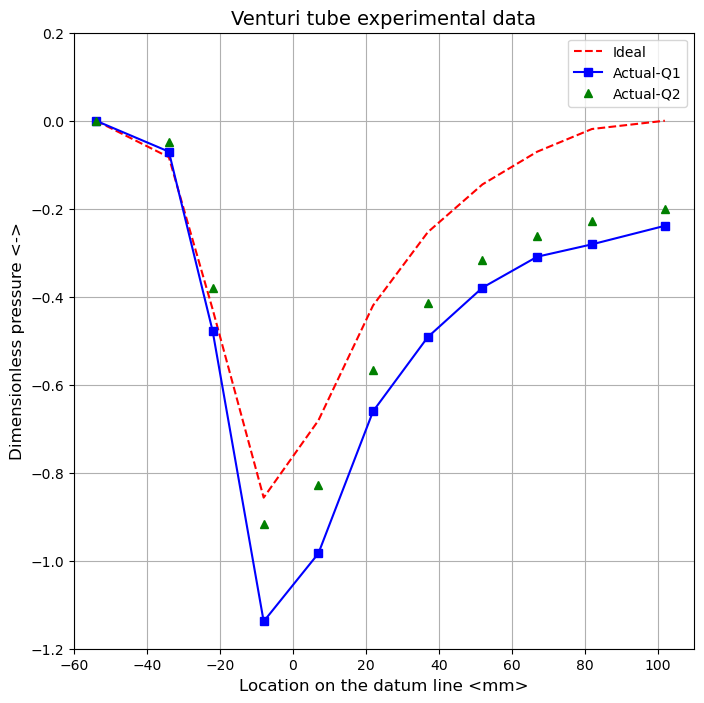

In [57]:
#set up our single subplot!
fig, ax = plt.subplots(figsize=(8,8))

#let's establish the x-axis with the variable "x_values"

#And establish our y-axis values with the following variables:
#ideal_dimLess_pressure
#actualQ1_dimLess_pressure
#actualQ2_dimLess_pressure

# red dashes, blue dots and green triangles
ax.plot(x_values, ideal_dimLess_pressure, color='r', linestyle='--', label='Ideal')
ax.plot(x_values, actualQ1_dimLess_pressure, color='b', marker='s', label='Actual-Q1') 
ax.plot(x_values, actualQ2_dimLess_pressure, 'g^', label='Actual-Q2') 

#and lets get a little fancy an add some labeling
ax.set_xlabel('Location on the datum line <mm>', fontsize=12)
ax.set_ylabel('Dimensionless pressure <->', fontsize=12)

#and maybe a title for our plot
ax.set_title('Venturi tube experimental data', fontsize=14)

#ax.text(x, y) just puts a textbox at this coordinate
#ax.text(1, 45, 'Look I can type in here too!!')

#ax.axis([x1, x2, y1, y2]) limits the view we want to see
ax.axis([-60, 110, -1.2, 0.2])

#ax.grid() adds a grid to the plot
ax.grid()

#ax.lengend() adds a legend (and finally a semi-colon to eliminate the default printing)
ax.legend();

## Save the above plot as a png-file

Note that `fig` is the variable assigned to the plot above. 
Review the cell with the plotting code.
The following line of code will save the above plot in the same working directory where the the jupyter notebook was saved. 

In [58]:
fig.savefig('Bulusu_Bengisu-Bera-Niazi-Truemper_LawFirm.png')

## Now that you learned how to run a python code that plots your experimental data, 

### You should 
1. Use the excel formatted template to input your own data gathered in the lab
2. Try adapting this Python code to plot your own data from lab. 
3. Replace the data in this code with your own experimental data, 
4. Assign your own file names for the data you gathered in the lab, 
5. Provide your own legend, variable names etc.

### Ultimately, you need to submit a working code that works with your experimental data. 

### Only a working code that is written by you will be graded.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=928a4826-6d7d-44bd-b128-d6cd83127a49' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>